In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
df = pd.read_csv("/content/UCI_Credit_Card.csv", on_bad_lines='skip')

In [32]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [33]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


# **Checking for and Removing Duplicate Rows**
It's important to identify and handle duplicate entries in a dataset as they can skew analysis and model training. We will first check if any rows are exact duplicates, and if so, remove them to ensure data integrity.

In [34]:
print(f"Number of duplicate rows before removal: {df.duplicated().sum()}")

# Remove duplicate rows
df_cleaned = df.drop_duplicates().reset_index(drop=True)

print(f"Number of rows after removing duplicates: {df_cleaned.shape[0]}")
print(f"Number of duplicate rows after removal: {df_cleaned.duplicated().sum()}")

Number of duplicate rows before removal: 0
Number of rows after removing duplicates: 30000
Number of duplicate rows after removal: 0


In [35]:
df.isnull().sum()

,0
ID,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0


-There is no null(missing) values

In [36]:
df.nunique()

,0
ID,30000
LIMIT_BAL,81
SEX,2
EDUCATION,7
MARRIAGE,4
AGE,56
PAY_0,11
PAY_2,11
PAY_3,11
PAY_4,11


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

-They are categorical but the important thing is there are no strings that need to be converted into numbers.

-normalization and class balancing is after the EDA step, now going to the EDA.

### ***EDA***

/tmp/ipykernel_2602/941409347.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='default.payment.next.month', data=df, palette='viridis')


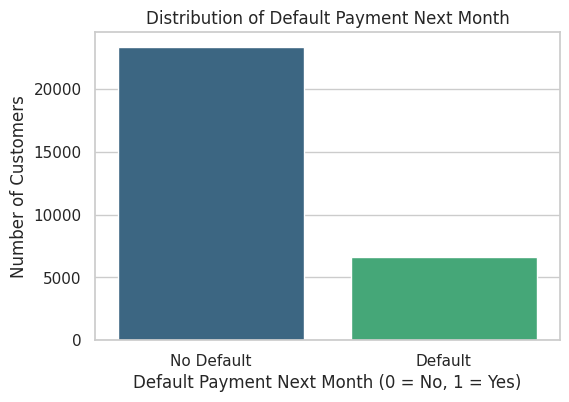

In [38]:
plt.figure(figsize=(6, 4))
sns.countplot(x='default.payment.next.month', data=df, palette='viridis')
plt.title('Distribution of Default Payment Next Month')
plt.xlabel('Default Payment Next Month (0 = No, 1 = Yes)')
plt.ylabel('Number of Customers')
plt.xticks([0, 1], ['No Default', 'Default'])
plt.show()

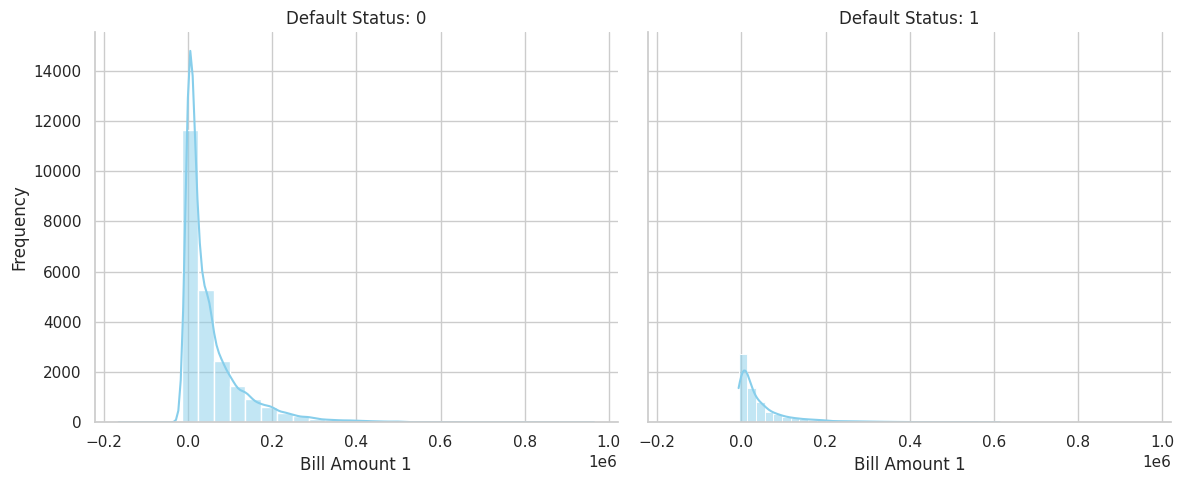

In [39]:
# Set up the visualization style
sns.set(style="whitegrid")

# Create a FacetGrid to show two plots based on the default status
g = sns.FacetGrid(df, col="default.payment.next.month", height=5, aspect=1.2)
g.map(sns.histplot, "BILL_AMT1", bins=30, kde=True, color="skyblue")

# Add titles and labels
g.set_titles("Default Status: {col_name}")
g.set_axis_labels("Bill Amount 1", "Frequency")

plt.tight_layout()
plt.show()

-Bill Amount 1 = BILL_AMT1 (amount of debt that you have accumulated) (as what will be shown later on in the Biserial correlation heatmap, it is not the best feature)


-the two graphs show the amount of debt that one accumulated in month september, now for the people with default status 0 (paid successfully in the next month october), it is natural that they have a good history with the bank and are allowed to borrow more money from the bank resulting in a higher debt, but they would pay anyways, so the range of the status = 0 curve is greater than the range of status = 1, those are actually the people that didn't pay on time and have a bad history, so it is natural that the bank wouldn't lend them more money, resulting in a smaller range in the histogram

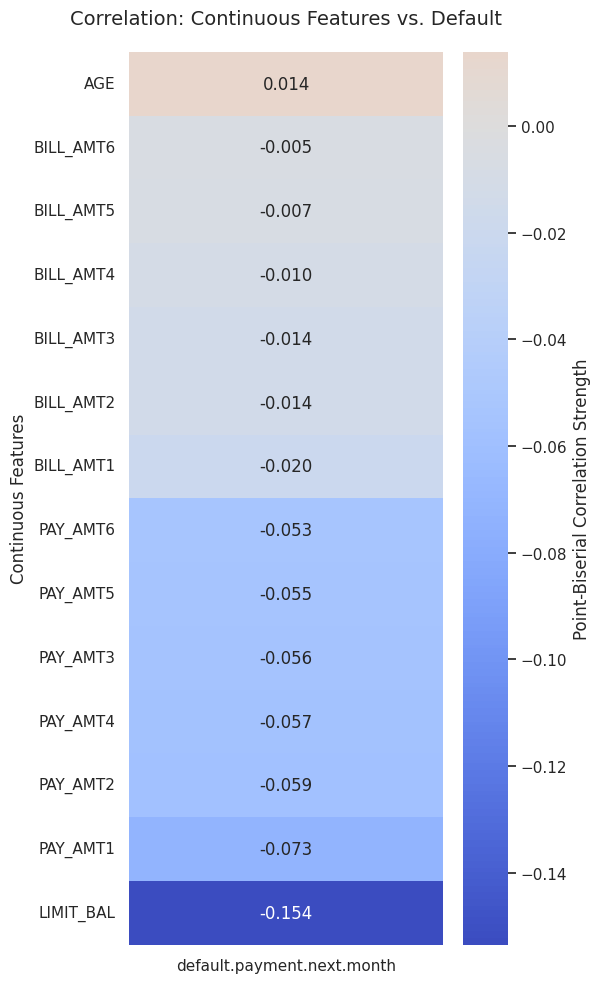

In [40]:

# 1. Define ONLY your continuous features and the binary target
continuous_features = [
    'LIMIT_BAL', 'AGE',
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
]
target = 'default.payment.next.month'

# 2. Create a subset dataframe.
# This prevents categorical/ordinal columns (like EDUCATION or PAY_0) from entering the Pearson calculation
df_subset = df[continuous_features + [target]]

# 3. Calculate the standard Pearson correlation matrix.
# Because the target is strictly 0 and 1, the math behind the scenes
# automatically yields the Point-Biserial correlation for that column.
corr_matrix = df_subset.corr()

# 4. Isolate the target column and sort it from strongest positive to strongest negative
target_corr = corr_matrix[[target]].sort_values(by=target, ascending=False)

# 5. Drop the target's correlation with itself (1.0) so it doesn't skew the heatmap colors
target_corr = target_corr.drop(target)

# 6. Plot the Linear Heatmap
plt.figure(figsize=(6, 10))

# We use sns.heatmap and pass our single-column dataframe
sns.heatmap(target_corr,
            annot=True,         # Show the actual correlation numbers
            cmap='coolwarm',    # Red for positive correlation, Blue for negative
            fmt='.3f',          # Format numbers to 3 decimal places
            center=0,           # Force the white/neutral color to sit exactly at 0
            cbar_kws={'label': 'Point-Biserial Correlation Strength'})

plt.title('Correlation: Continuous Features vs. Default', pad=20, fontsize=14)
plt.ylabel('Continuous Features')
plt.tight_layout()
plt.show()

-For The LIMIT_BAL(the other features are -vely correlated with the same logic): this is the limit on your account credits, it is natural that the bank offers higher limits on people who pay on time ( status = 0 -> less status), so the correlation when using a special correlation (point biserial correlation) between a continuous and discrete feature results in a negative correlation

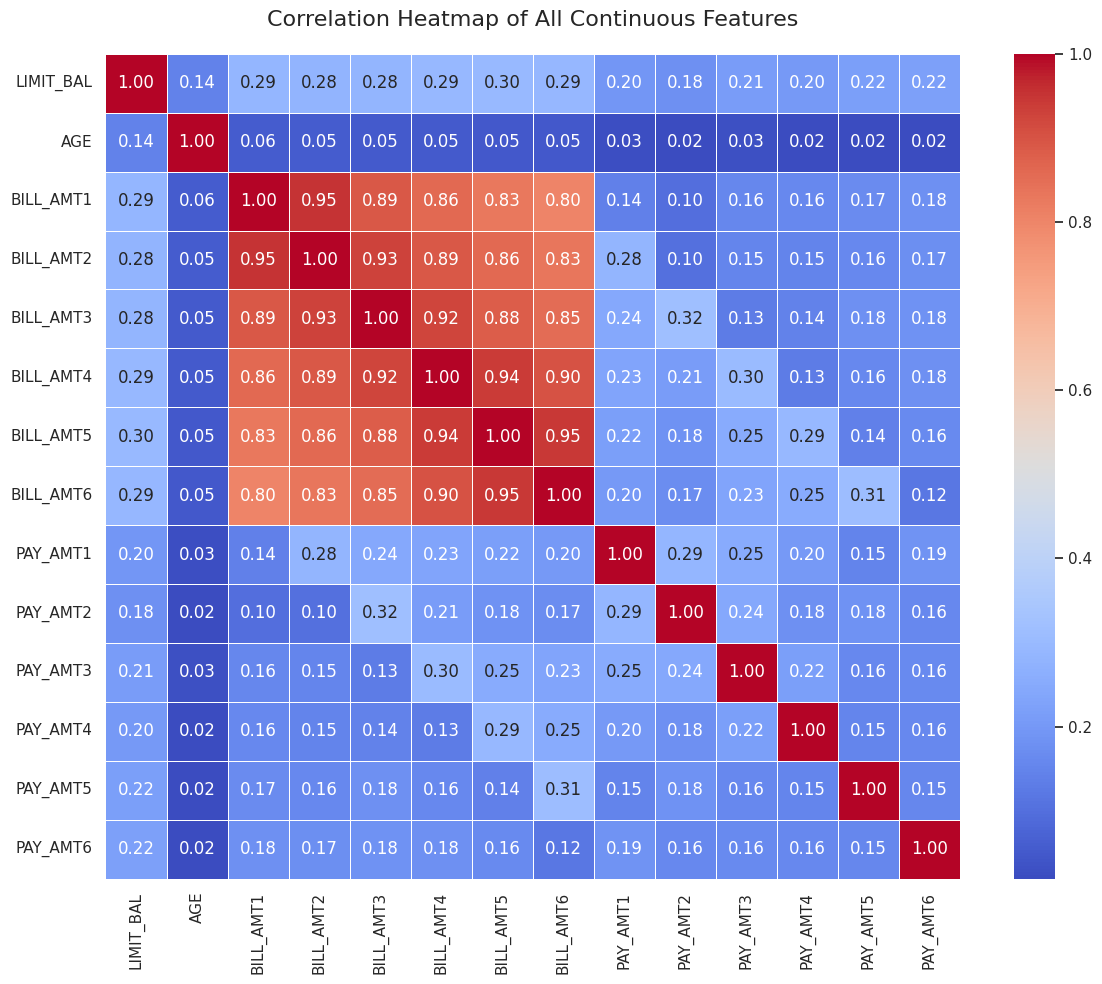

In [41]:
# Ensure df is loaded, assuming it might not be in the current kernel state
df = pd.read_csv("/content/UCI_Credit_Card.csv")

# Identify all continuous features from the dataframe, excluding 'ID' and the target
all_continuous_features = [
    'LIMIT_BAL', 'AGE',
    'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6',
    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
]

df_continuous = df[all_continuous_features]

# Calculate the Pearson correlation matrix for the continuous features
corr_matrix_continuous = df_continuous.corr()

# Plot the full heatmap
plt.figure(figsize=(12, 10)) # Adjust figure size for better readability
sns.heatmap(corr_matrix_continuous,
            annot=True,         # Show the correlation coefficients on the heatmap
            cmap='coolwarm',    # Choose a diverging colormap
            fmt='.2f',          # Format numbers to 2 decimal places
            linewidths=.5)      # Add lines between cells for better visual separation

plt.title('Correlation Heatmap of All Continuous Features', pad=20, fontsize=16)
plt.tight_layout()
plt.show()

This plot "Heatmap" is a visual way to see how closely related features in our dataset are to each other.

there's a very strong correlation among BILL_AMT1 through BILL_AMT6. This is expected, as these represent bill amounts over successive months; if you have a high bill one month, you're likely to have a high bill the next, assuming you haven't paid it all off. Similarly, PAY_AMT variables (PAY_AMT1 through PAY_AMT6) show how much someone paid.

In [42]:
print(f"Class Distribution:")
df['default.payment.next.month'].value_counts()

Class Distribution:


,count
default.payment.next.month,
0,23364
1,6636


-the data needs class balancing before getting fed into the classifier model, but it was necessary to plot and visualize the data before balancing to not remove any data when visualizing

### ***Preprocessing(Decision Tree)***

In [7]:
from sklearn.utils import shuffle

# Separate the classes
df_no_default = df[df['default.payment.next.month'] == 0]
df_default = df[df['default.payment.next.month'] == 1]

# Get the count of the minority class
n_samples = len(df_default)

# Shuffle and undersample the majority class
df_no_default_undersampled = shuffle(df_no_default, random_state=42).iloc[:n_samples]

# Combine back into a new balanced DataFrame
newDf = pd.concat([df_no_default_undersampled, df_default])

# Shuffle the final balanced dataset
newDf = shuffle(newDf, random_state=42).reset_index(drop=True)

print(f"Original class distribution:\n{df['default.payment.next.month'].value_counts()}")
print(f"\nNew balanced class distribution:\n{newDf['default.payment.next.month'].value_counts()}")
display(newDf)

Original class distribution:
default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64

New balanced class distribution:
default.payment.next.month
0    6636
1    6636
Name: count, dtype: int64


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,5212,50000.0,1,2,2,23,2,2,-1,0,...,19649.0,20064.0,19691.0,1200.0,50189.0,682.0,710.0,690.0,693.0,0
1,9786,80000.0,2,2,2,25,1,2,0,0,...,33734.0,29822.0,30966.0,0.0,2000.0,2444.0,0.0,3000.0,1000.0,1
2,21122,170000.0,1,2,2,31,0,0,0,0,...,12770.0,12971.0,13312.0,1610.0,2500.0,1600.0,711.0,700.0,700.0,0
3,23871,300000.0,1,2,2,27,0,0,-1,-1,...,17648.0,36732.0,1000.0,2800.0,1983.0,17652.0,36183.0,1002.0,0.0,0
4,16845,240000.0,1,1,1,36,1,-2,-2,-2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13267,23779,50000.0,2,3,2,50,1,-2,-2,-2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
13268,6647,140000.0,1,2,1,29,0,0,0,0,...,132038.0,131961.0,124256.0,6696.0,5000.0,4866.0,5300.0,5055.0,5000.0,0
13269,18494,200000.0,2,2,2,25,-2,-2,-2,-2,...,1599.0,0.0,0.0,169.0,1192.0,1599.0,0.0,0.0,0.0,0
13270,19503,50000.0,2,1,2,44,0,0,0,0,...,16995.0,17490.0,18253.0,1500.0,2000.0,5000.0,778.0,1200.0,752.0,0


this is the class balancing part that was delayed until this moment

-now that we chose decision tree as our first model, it needs no scaling or normalization as it puts the threshold at any numbers in the tree and splits, so it wouldn't matter if all of the features were not normalized, no need of handling non-linearity

In [388]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
feature_columns =  ['LIMIT_BAL', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4','PAY_AMT5',
       'PAY_AMT6',  'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6' ]
X = newDf[feature_columns]
y = newDf['default.payment.next.month']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [391]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42,
                                       min_samples_split = 215,
                                       max_depth = 8
                                      )

# Train the model
dt_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred = dt_classifier.predict(X_test)


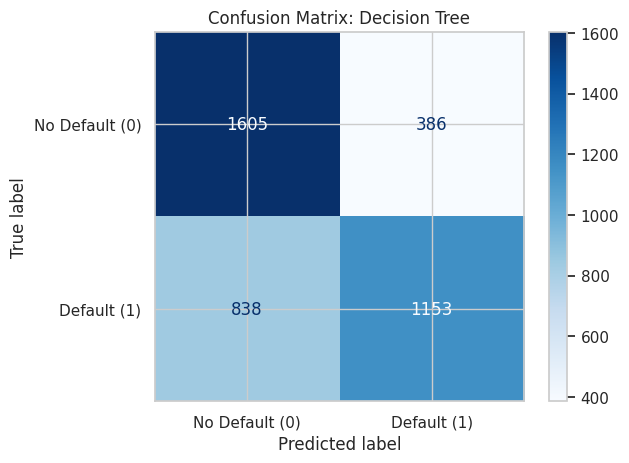


Decision Tree Classifier Metrics:
Accuracy:  0.6926
F1-Score:  0.6533


In [390]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, \
 f1_score, confusion_matrix, ConfusionMatrixDisplay


# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# 1. Generate the raw confusion matrix numbers
cm = confusion_matrix(y_test, y_pred)

# 2. Create the display object, adding custom labels for clarity
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['No Default (0)', 'Default (1)'])

# 3. Plot it with a nice color map (cmap)
disp.plot(cmap='Blues', values_format='d') # 'd' formats numbers as integers

# 4. Add a title and show the plot
plt.title("Confusion Matrix: Decision Tree")
plt.show()

print(f"\nDecision Tree Classifier Metrics:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"F1-Score:  {f1:.4f}")

Features used for training: ['LIMIT_BAL']

Decision Tree Classifier Metrics:

Accuracy:  0.5786


F1-Score:  0.5909



Features used for training: ['LIMIT_BAL', 'PAY_AMT1']

Decision Tree Classifier Metrics:

Accuracy:  0.5701

F1-Score:  0.5883


best max_depth to prevent overfitting: 2

Features used for training: ['LIMIT_BAL', 'PAY_AMT1']


F1-Score:  0.6497

min_samples_split had no effect over the metrics, zero change

-adding the third most correlated feature but this time with restrictions(max_depth) on the model to prevent overfitting gave better results than just adding

now trying with the three most important features with the best hyperparameters

Features used for training: ['LIMIT_BAL', 'PAY_AMT1', 'PAY_AMT2']

max_depth the best one was 5

Decision Tree Classifier Metrics:

Accuracy:  0.6185


F1-Score:  0.6580

Features used for training: ['LIMIT_BAL', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT4']

max_depth = 8 for best result


Decision Tree Classifier Metrics:

Accuracy:  0.6215


F1-Score:  0.6413


Features used for training: ['LIMIT_BAL', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT4', 'PAY_AMT3']

max_depth = 3 for best result

Decision Tree Classifier Metrics:

Accuracy:  0.5924

F1-Score:  0.6611


Features used for training: ['LIMIT_BAL', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT4', 'PAY_AMT3', 'PAY_AMT5']

max_depth = 3

Decision Tree Classifier Metrics:

Accuracy:  0.5924

F1-Score:  0.6611

Features used for training: ['LIMIT_BAL', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT4', 'PAY_AMT3', 'PAY_AMT5', 'PAY_AMT6']

max_depth = 8

Decision Tree Classifier Metrics:

Accuracy:  0.6248

F1-Score:  0.6107


features used for training: ['LIMIT_BAL', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT4','PAY_AMT5', 'PAY_AMT6',  'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6' ]

Decision Tree Classifier Metrics:
Accuracy:  0.6921
F1-Score:  0.6479

### ***Preprocessing(Naive Bayes)***

---





*   Shuffling + class balancing
*   removing the features that are highly correlated (no need)
*   bin continous variables into discrete ones (was unnecessary meaning that we were dealling with data that was gaussian in the first place and lead to worse performance)
*   Converting Categorical values into numerical ones (no need)
*   Managing Missing Values (no need)
*   Tokenization (no need here)








In [296]:
# Separate the classes
df_no_default = df[df['default.payment.next.month'] == 0]
df_default = df[df['default.payment.next.month'] == 1]

# Get the count of the minority class
n_samples = len(df_default)

# Shuffle and undersample the majority class
df_no_default_undersampled = shuffle(df_no_default, random_state=42).iloc[:n_samples]

# Combine back into a new balanced DataFrame
newDf = pd.concat([df_no_default_undersampled, df_default])

# Shuffle the final balanced dataset
newDf = shuffle(newDf, random_state=42).reset_index(drop=True)

print(f"Original class distribution:\n{df['default.payment.next.month'].value_counts()}")
print(f"\nNew balanced class distribution:\n{newDf['default.payment.next.month'].value_counts()}")
display(newDf)

Original class distribution:
default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64

New balanced class distribution:
default.payment.next.month
0    6636
1    6636
Name: count, dtype: int64


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,5212,50000.0,1,2,2,23,2,2,-1,0,...,19649.0,20064.0,19691.0,1200.0,50189.0,682.0,710.0,690.0,693.0,0
1,9786,80000.0,2,2,2,25,1,2,0,0,...,33734.0,29822.0,30966.0,0.0,2000.0,2444.0,0.0,3000.0,1000.0,1
2,21122,170000.0,1,2,2,31,0,0,0,0,...,12770.0,12971.0,13312.0,1610.0,2500.0,1600.0,711.0,700.0,700.0,0
3,23871,300000.0,1,2,2,27,0,0,-1,-1,...,17648.0,36732.0,1000.0,2800.0,1983.0,17652.0,36183.0,1002.0,0.0,0
4,16845,240000.0,1,1,1,36,1,-2,-2,-2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13267,23779,50000.0,2,3,2,50,1,-2,-2,-2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
13268,6647,140000.0,1,2,1,29,0,0,0,0,...,132038.0,131961.0,124256.0,6696.0,5000.0,4866.0,5300.0,5055.0,5000.0,0
13269,18494,200000.0,2,2,2,25,-2,-2,-2,-2,...,1599.0,0.0,0.0,169.0,1192.0,1599.0,0.0,0.0,0.0,0
13270,19503,50000.0,2,1,2,44,0,0,0,0,...,16995.0,17490.0,18253.0,1500.0,2000.0,5000.0,778.0,1200.0,752.0,0


shuffling + class balancing

selecting only one from the groups of columns that are highly correlated to each other due to the model double counting the info, the ones that are highly correlated are of less importance than the ones that are selected above

In [297]:
#columns_to_bin = [
#    'LIMIT_BAL',
#    'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'
#]


#for col in columns_to_bin:
#    newDf[col] = pd.qcut(newDf[col], q=30, labels=False, duplicates='drop')

#for col in [ 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']:
#    print(f"column {col} has: {newDf[col].unique()} ")
#    newDf[col] = pd.cut(newDf[col], bins=newDf[col].nunique(), labels=False, duplicates='drop')
#    print(f"column {col} has: {newDf[col].unique()} ")



#newDf.describe()

this is the binning of the continous variables into discrete groups(from 0 - 9), lead to worse performance and even the conversion of the -ve values to other ones lead to worse performance too

In [298]:
# 1. Define features and target
features = ['LIMIT_BAL', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3' ,'PAY_AMT4','PAY_AMT5',
       'PAY_AMT6',  'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6' ]

X = newDf[features]
y = newDf['default.payment.next.month']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [299]:
nb_model = GaussianNB()

nb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = nb_model.predict(X_test)

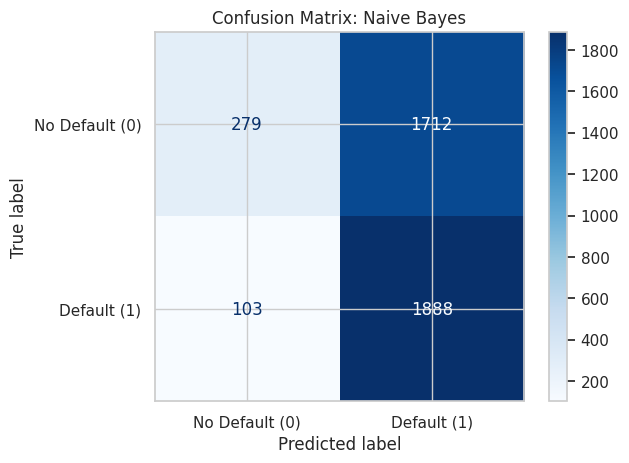


Naive Bayes Classifier Metrics:
Accuracy:  0.5442
F1-Score:  0.6754


In [300]:
from sklearn.naive_bayes import GaussianNB

# 1. Generate the raw confusion matrix numbers
cm = confusion_matrix(y_test, y_pred)

# 2. Create the display object, adding custom labels for clarity
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['No Default (0)', 'Default (1)'])

# 3. Plot it with a nice color map (cmap)
disp.plot(cmap='Blues', values_format='d') # 'd' formats numbers as integers

# 4. Add a title and show the plot
plt.title("Confusion Matrix: Naive Bayes")
plt.show()


# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nNaive Bayes Classifier Metrics:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"F1-Score:  {f1:.4f}")

The hyperparameters of gaussianNB are rarely tuned in practice, it is a strong baseline becasue its parameters are derived directly from the data's mean variance, in naive, feature engineering is of greater importance

### **Preprocessing(Logistic Regression)**




*cleaning: impute or drop NaN (don't need)   

*encoding: already done

*standardization

*class balancing




In [8]:

# Separate the classes
df_no_default = df[df['default.payment.next.month'] == 0]
df_default = df[df['default.payment.next.month'] == 1]

# Get the count of the minority class
n_samples = len(df_default)

# Shuffle and undersample the majority class
df_no_default_undersampled = shuffle(df_no_default, random_state=42).iloc[:n_samples]

# Combine back into a new balanced DataFrame
newDf = pd.concat([df_no_default_undersampled, df_default])

# Shuffle the final balanced dataset
newDf = shuffle(newDf, random_state=42).reset_index(drop=True)

print(f"Original class distribution:\n{df['default.payment.next.month'].value_counts()}")
print(f"\nNew balanced class distribution:\n{newDf['default.payment.next.month'].value_counts()}")
display(newDf)

Original class distribution:
default.payment.next.month
0    23364
1     6636
Name: count, dtype: int64

New balanced class distribution:
default.payment.next.month
0    6636
1    6636
Name: count, dtype: int64


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,5212,50000.0,1,2,2,23,2,2,-1,0,...,19649.0,20064.0,19691.0,1200.0,50189.0,682.0,710.0,690.0,693.0,0
1,9786,80000.0,2,2,2,25,1,2,0,0,...,33734.0,29822.0,30966.0,0.0,2000.0,2444.0,0.0,3000.0,1000.0,1
2,21122,170000.0,1,2,2,31,0,0,0,0,...,12770.0,12971.0,13312.0,1610.0,2500.0,1600.0,711.0,700.0,700.0,0
3,23871,300000.0,1,2,2,27,0,0,-1,-1,...,17648.0,36732.0,1000.0,2800.0,1983.0,17652.0,36183.0,1002.0,0.0,0
4,16845,240000.0,1,1,1,36,1,-2,-2,-2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13267,23779,50000.0,2,3,2,50,1,-2,-2,-2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
13268,6647,140000.0,1,2,1,29,0,0,0,0,...,132038.0,131961.0,124256.0,6696.0,5000.0,4866.0,5300.0,5055.0,5000.0,0
13269,18494,200000.0,2,2,2,25,-2,-2,-2,-2,...,1599.0,0.0,0.0,169.0,1192.0,1599.0,0.0,0.0,0.0,0
13270,19503,50000.0,2,1,2,44,0,0,0,0,...,16995.0,17490.0,18253.0,1500.0,2000.0,5000.0,778.0,1200.0,752.0,0


this is the class balancing

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Define features and target
X = newDf.drop(columns=['ID', 'default.payment.next.month'])
X = X[['LIMIT_BAL', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3' ,'PAY_AMT4','PAY_AMT5',
       'PAY_AMT6',  'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6' ]]
y = newDf['default.payment.next.month']

# 2. Split FIRST
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Fit on Train, Transform both
scaler = StandardScaler()

# We only .fit() on X_train to prevent leakage
X_train_scaled = scaler.fit_transform(X_train)

# We only .transform() X_test using X_train's mean/std
X_test_scaled = scaler.transform(X_test)

Standardization step

In [303]:
from sklearn.linear_model import LogisticRegression

# 1. Initialize the Logistic Regression model
log_reg = LogisticRegression(random_state=42, solver='liblinear')

log_reg.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = log_reg.predict(X_test_scaled)


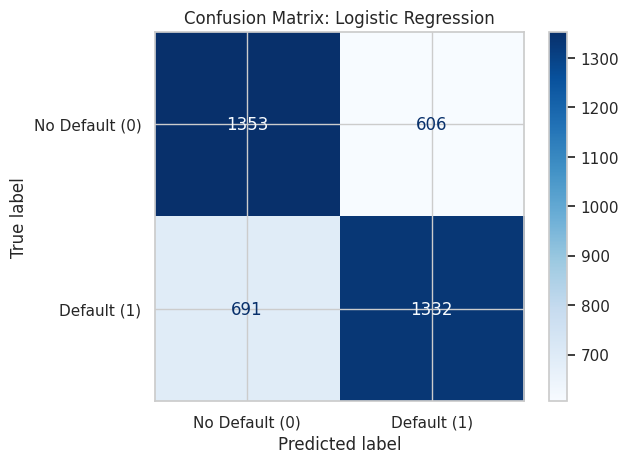


Logistic Regression Classifier Metrics:
Accuracy:  0.6743
F1-Score:  0.6726


In [304]:

# 1. Generate the raw confusion matrix numbers
cm = confusion_matrix(y_test, y_pred)

# 2. Create the display object, adding custom labels for clarity
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['No Default (0)', 'Default (1)'])

# 3. Plot it with a nice color map (cmap)
disp.plot(cmap='Blues', values_format='d') # 'd' formats numbers as integers

# 4. Add a title and show the plot
plt.title("Confusion Matrix: Logistic Regression")
plt.show()


# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\nLogistic Regression Classifier Metrics:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"F1-Score:  {f1:.4f}")


features: ['LIMIT_BAL', 'PAY_AMT1']

Accuracy:  0.6102

F1-Score:  0.6372


features: ['LIMIT_BAL', 'PAY_AMT1', 'PAY_AMT2']

Accuracy:  0.6072

F1-Score:  0.6382

features: ['LIMIT_BAL', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT4']

Accuracy:  0.6072

F1-Score:  0.6375

features: ['LIMIT_BAL', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3' ,'PAY_AMT4','PAY_AMT5', 'PAY_AMT6',  'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6' ]

Accuracy:  0.6743

F1-Score:  0.6726


### **Trying Logistic Regression Hyperparameters**

In [11]:
# 1. Define your exact features & target
feature_cols = ['LIMIT_BAL', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5',
                'PAY_AMT6', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
X = newDf[feature_cols]
y = newDf['default.payment.next.month']

# 2. Split FIRST
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Scale & PRESERVE feature names (StandardScaler returns numpy array by default)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test), columns=feature_cols)

# 4. Train Logistic Regression with L1 (Lasso) penalty
lasso_lr = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    C=1.0,               # ↓ C = more features zeroed out | ↑ C = fewer zeroed
    random_state=42,
    max_iter=1000
)
lasso_lr.fit(X_train_scaled, y_train)

# 5. Extract coefficients & map to your exact feature names
coef = lasso_lr.coef_[0]
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': coef,
    'Abs_Coefficient': np.abs(coef)
})

# Lasso automatically zeros out irrelevant features → filter & sort
best_features = importance_df[importance_df['Coefficient'] != 0].sort_values('Abs_Coefficient', ascending=False)

# 6. Display results
print(f"✅ Lasso kept {len(best_features)} / {len(feature_cols)} features (C={lasso_lr.C})")
print("\n🏆 Selected Features Ranked by Importance:")
print(best_features[['Feature', 'Coefficient']])

# Quick performance check
test_acc = accuracy_score(y_test, lasso_lr.predict(X_test_scaled))
print(f"\n📈 Test Accuracy: {test_acc:.4f}")

✅ Lasso kept 13 / 13 features (C=1.0)

🏆 Selected Features Ranked by Importance:
      Feature  Coefficient
7       PAY_0     0.639484
2    PAY_AMT2    -0.222265
1    PAY_AMT1    -0.111332
11      PAY_5     0.094577
8       PAY_2     0.090152
5    PAY_AMT5    -0.089418
0   LIMIT_BAL    -0.080025
3    PAY_AMT3    -0.076759
9       PAY_3     0.075903
6    PAY_AMT6    -0.045756
12      PAY_6    -0.041767
4    PAY_AMT4    -0.036148
10      PAY_4    -0.018991

📈 Test Accuracy: 0.6753


-lasso: restrict every single coefficient making the least important ones drop to zero, keeping only the influence of the strongest feature there is

-so as shown above, the PAY_0 is the one that survived the lasso penalty, so it is the most important feature here

### **ROC / AUC**

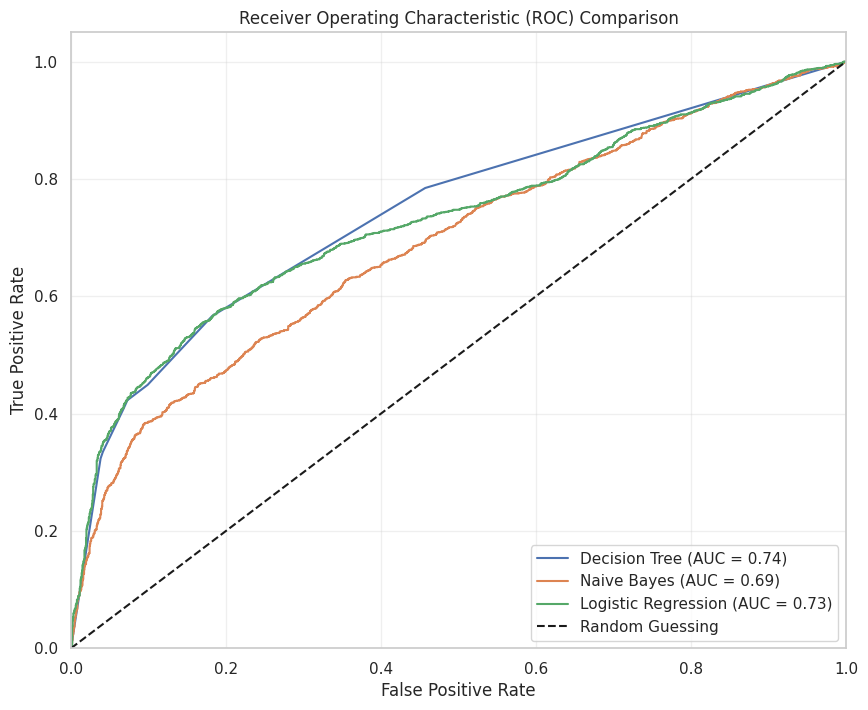

In [305]:
from sklearn.metrics import roc_curve, auc

# 1. Prepare to store results
plt.figure(figsize=(10, 8))

# --- Decision Tree ROC ---
# Using the features specifically used in your DT cell
X_dt = newDf[['LIMIT_BAL', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3' ,'PAY_AMT4','PAY_AMT5',
       'PAY_AMT6',  'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6' ]]
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(X_dt, y, test_size=0.3, random_state=42, stratify=y)
dt_probs = dt_classifier.predict_proba(X_test_dt)[:, 1]
fpr_dt, tpr_dt, _ = roc_curve(y_test_dt, dt_probs)
roc_auc_dt = auc(fpr_dt, tpr_dt)
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {roc_auc_dt:.2f})')

# --- Naive Bayes ROC ---
# Using X_test from the NB cell context
nb_probs = nb_model.predict_proba(X_test)[:, 1]
fpr_nb, tpr_nb, _ = roc_curve(y_test, nb_probs)
roc_auc_nb = auc(fpr_nb, tpr_nb)
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC = {roc_auc_nb:.2f})')

# --- Logistic Regression ROC ---
# Using the scaled test data from the Logistic Regression cell context
# Note: Cell HBIejMO_KgWE was using nb_model incorrectly in previous turn,
# so we use the actual log_reg model here.
log_probs = log_reg.predict_proba(X_test_scaled)[:, 1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, log_probs)
roc_auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.2f})')

# 2. Plot formatting
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Comparison')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()